# World Happiness Report (2005–2021) Project

This notebook explores the World Happiness Report dataset, which contains survey-based measures of happiness from over 150 countries between 2005 and 2021. 
The goal of this project is to analyze global patterns of well-being and investigate how economic, social, and health factors relate to happiness. 
The workflow includes preprocessing the data, creating visualizations, and building a narrative around insights discovered along the way.


## 1. Import libraries that will be used

In [27]:
%pip install scikit-learn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

  Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.16.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 226.8 kB/s eta 0:00:00a 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.6/28.6 MB 119.9 kB/s eta 0:00:0000:0100:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## 2. Read in the Data and create a DataFrame

In [61]:
df_happiness = pd.read_csv("/Users/kathrynkopczenski/Documents/ITCS3162/World Happiness Report 2005-2021.csv")
df_happiness.head()

,Country name,Year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,0.267919,0.435440


In [63]:
df_happiness.shape

(2089, 12)

## 3. Preprocessing

**-Handling Null Values**

In [42]:
#Check and see how many null values are in the dataset
df_happiness.isna().sum()

Country name                        0
Year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
dtype: int64

In [41]:
# Drop "confidence in national government" (too many nulls to be useful here)
if 'Confidence in national government' in df_happiness.columns:
    df_happiness = df_happiness.drop(columns=['Confidence in national government'])

# Fill other numeric columns with their column mean
cols_to_fill = ['Log GDP per capita','Social support','Healthy life expectancy at birth',
                'Freedom to make life choices','Generosity','Perceptions of corruption',
                'Positive affect','Negative affect']

for col in cols_to_fill:
    df_happiness[col] = df_happiness[col].fillna(df_happiness[col].mean())

# Quick check again
print(df_happiness.isna().sum())


Country name                        0
Year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
dtype: int64


**-Standardizing Column Names**

To ensure consistency and avoid potential issues, we will standardize the column names by converting them to lowercase and removing special characters.

In [67]:
df_happiness.columns = (df_happiness.columns
                        .str.strip()
                        .str.lower()
                        .str.replace(' ', '_')
                        .str.replace(r'[^0-9a-zA-Z_]+', '', regex=True))
print(df_happiness.columns)



Index(['country_name', 'year', 'life_ladder', 'log_gdp_per_capita',
       'social_support', 'healthy_life_expectancy_at_birth',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption', 'positive_affect', 'negative_affect',
       'confidence_in_national_government'],
      dtype='object')


**-Convert Year to integer to ensure it will be int type for plotting later.**

In [68]:
df_happiness['year'] = df_happiness['year'].astype(int)


**-Check for duplicates & reordering indexes**

In [69]:
df_happiness = df_happiness.drop_duplicates(subset=['country_name','year'])
df_happiness = df_happiness.reset_index(drop=True)
print(df_happiness.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country_name                       2089 non-null   object 
 1   year                               2089 non-null   int64  
 2   life_ladder                        2089 non-null   float64
 3   log_gdp_per_capita                 2062 non-null   float64
 4   social_support                     2076 non-null   float64
 5   healthy_life_expectancy_at_birth   2031 non-null   float64
 6   freedom_to_make_life_choices       2057 non-null   float64
 7   generosity                         2009 non-null   float64
 8   perceptions_of_corruption          1976 non-null   float64
 9   positive_affect                    2065 non-null   float64
 10  negative_affect                    2073 non-null   float64
 11  confidence_in_national_government  1873 non-null   float

## 5. Mapping

To simplify comparisons, I mapped each country to one of six broad regions (Africa, Asia, Europe, North America, South America, Oceania).  


In [70]:
# ===== Add Region Column =====

# Base mapping into 6 broad regions
region_map = {
    # Africa
    'Algeria':'Africa','Angola':'Africa','Benin':'Africa','Botswana':'Africa','Burkina Faso':'Africa',
    'Burundi':'Africa','Cameroon':'Africa','Cape Verde':'Africa','Central African Republic':'Africa',
    'Chad':'Africa','Comoros':'Africa','Congo (Brazzaville)':'Africa','Congo (Kinshasa)':'Africa',
    'Djibouti':'Africa','Egypt':'Africa','Equatorial Guinea':'Africa','Eritrea':'Africa','Eswatini':'Africa',
    'Ethiopia':'Africa','Gabon':'Africa','Gambia':'Africa','Ghana':'Africa','Guinea':'Africa',
    'Guinea-Bissau':'Africa','Ivory Coast':'Africa','Kenya':'Africa','Lesotho':'Africa','Liberia':'Africa',
    'Libya':'Africa','Madagascar':'Africa','Malawi':'Africa','Mali':'Africa','Mauritania':'Africa',
    'Mauritius':'Africa','Morocco':'Africa','Mozambique':'Africa','Namibia':'Africa','Niger':'Africa',
    'Nigeria':'Africa','Rwanda':'Africa','Sao Tome and Principe':'Africa','Senegal':'Africa','Seychelles':'Africa',
    'Sierra Leone':'Africa','Somalia':'Africa','South Africa':'Africa','South Sudan':'Africa','Sudan':'Africa',
    'Tanzania':'Africa','Togo':'Africa','Tunisia':'Africa','Uganda':'Africa','Zambia':'Africa','Zimbabwe':'Africa',
    
    # Asia
    'Afghanistan':'Asia','Armenia':'Asia','Azerbaijan':'Asia','Bahrain':'Asia','Bangladesh':'Asia',
    'Bhutan':'Asia','Brunei':'Asia','Cambodia':'Asia','China':'Asia','Cyprus':'Asia',
    'Georgia':'Asia','India':'Asia','Indonesia':'Asia','Iran':'Asia','Iraq':'Asia','Israel':'Asia',
    'Japan':'Asia','Jordan':'Asia','Kazakhstan':'Asia','Kuwait':'Asia','Kyrgyzstan':'Asia','Laos':'Asia',
    'Lebanon':'Asia','Malaysia':'Asia','Maldives':'Asia','Mongolia':'Asia','Myanmar':'Asia','Nepal':'Asia',
    'North Korea':'Asia','Oman':'Asia','Pakistan':'Asia','Palestine':'Asia','Philippines':'Asia','Qatar':'Asia',
    'Saudi Arabia':'Asia','Singapore':'Asia','South Korea':'Asia','Sri Lanka':'Asia','Syria':'Asia','Tajikistan':'Asia',
    'Thailand':'Asia','Timor-Leste':'Asia','Turkey':'Asia','Turkmenistan':'Asia','United Arab Emirates':'Asia',
    'Uzbekistan':'Asia','Vietnam':'Asia','Yemen':'Asia',
    
    # Europe
    'Albania':'Europe','Andorra':'Europe','Austria':'Europe','Belarus':'Europe','Belgium':'Europe',
    'Bosnia and Herzegovina':'Europe','Bulgaria':'Europe','Croatia':'Europe','Czech Republic':'Europe',
    'Denmark':'Europe','Estonia':'Europe','Finland':'Europe','France':'Europe','Germany':'Europe','Greece':'Europe',
    'Hungary':'Europe','Iceland':'Europe','Ireland':'Europe','Italy':'Europe','Kosovo':'Europe','Latvia':'Europe',
    'Lithuania':'Europe','Luxembourg':'Europe','Malta':'Europe','Moldova':'Europe','Monaco':'Europe',
    'Montenegro':'Europe','Netherlands':'Europe','North Macedonia':'Europe','Norway':'Europe','Poland':'Europe',
    'Portugal':'Europe','Romania':'Europe','Russia':'Europe','San Marino':'Europe','Serbia':'Europe','Slovakia':'Europe',
    'Slovenia':'Europe','Spain':'Europe','Sweden':'Europe','Switzerland':'Europe','Ukraine':'Europe','United Kingdom':'Europe',
    
    # North America (including Central America & Caribbean)
    'Antigua and Barbuda':'North America','Bahamas':'North America','Barbados':'North America','Belize':'North America',
    'Canada':'North America','Costa Rica':'North America','Cuba':'North America','Dominica':'North America',
    'Dominican Republic':'North America','El Salvador':'North America','Grenada':'North America','Guatemala':'North America',
    'Haiti':'North America','Honduras':'North America','Jamaica':'North America','Mexico':'North America','Nicaragua':'North America',
    'Panama':'North America','Saint Kitts and Nevis':'North America','Saint Lucia':'North America',
    'Saint Vincent and the Grenadines':'North America','Trinidad and Tobago':'North America','United States':'North America',
    
    # South America
    'Argentina':'South America','Bolivia':'South America','Brazil':'South America','Chile':'South America',
    'Colombia':'South America','Ecuador':'South America','Guyana':'South America','Paraguay':'South America',
    'Peru':'South America','Suriname':'South America','Uruguay':'South America','Venezuela':'South America',
    
    # Oceania
    'Australia':'Oceania','Fiji':'Oceania','Kiribati':'Oceania','Marshall Islands':'Oceania','Micronesia':'Oceania',
    'Nauru':'Oceania','New Zealand':'Oceania','Palau':'Oceania','Papua New Guinea':'Oceania','Samoa':'Oceania',
    'Solomon Islands':'Oceania','Tonga':'Oceania','Tuvalu':'Oceania','Vanuatu':'Oceania'
}

# Handle special cases (names different in your dataset)
extra_map = {
    'Czechia': 'Europe',
    'Hong Kong S.A.R. of China': 'Asia',
    'North Cyprus': 'Europe',
    'Palestinian Territories': 'Asia',
    'Somaliland region': 'Africa',
    'Taiwan Province of China': 'Asia'
}

# Update mapping with special cases
region_map.update(extra_map)

# Apply mapping to create a region column
df_happiness['region'] = df_happiness['country_name'].map(region_map)

# Verify no missing regions remain
print(df_happiness['region'].isna().sum())
print(df_happiness[['country_name','region']].head())


0
  country_name region
0  Afghanistan   Asia
1  Afghanistan   Asia
2  Afghanistan   Asia
3  Afghanistan   Asia
4  Afghanistan   Asia


In [71]:
df_happiness.head()

,country_name,year,life_ladder,log_gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption,positive_affect,negative_affect,confidence_in_national_government,region
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072,Asia
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545,Asia
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357,Asia
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386,Asia
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,0.267919,0.435440,Asia


## 6. Visualizations

## -Top 10 Happiest Countries in the World on Average

/var/folders/0w/0z2byg_114s3vhmjkpslm3dr0000gn/T/ipykernel_49831/1876662788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_country.values, y=avg_country.index, palette="viridis")


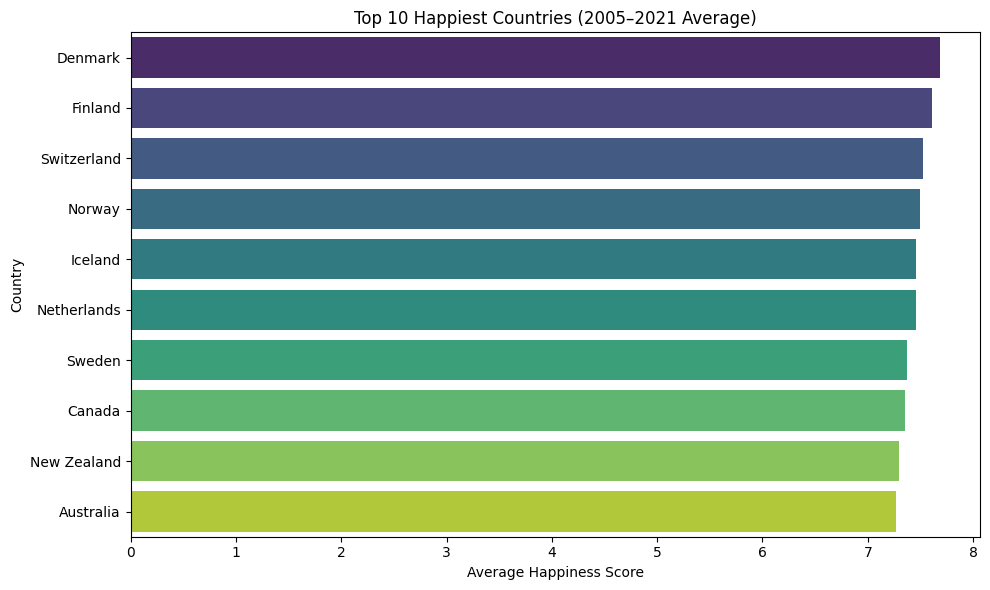

In [79]:
avg_country = df_happiness.groupby('country_name')['life_ladder'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_country.values, y=avg_country.index, palette="viridis")
plt.title("Top 10 Happiest Countries (2005–2021 Average)")
plt.xlabel("Average Happiness Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## -Heatmap

**What this shows:** This heatmap helps me spot which variables move most with happiness overall (positive or negative). I’ll use these signals to choose the next plots (e.g., scatterplots for the strongest relationships and regional/time breakdowns).


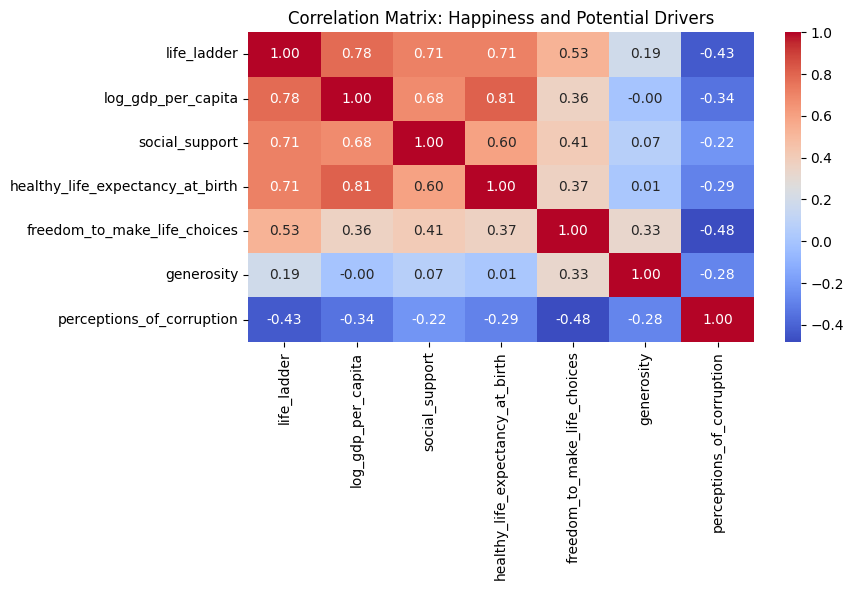

In [72]:
# Pick the core numeric columns (only those that exist in your DataFrame)
candidate_cols = [
    'life_ladder',
    'log_gdp_per_capita',
    'social_support',
    'healthy_life_expectancy_at_birth',
    'freedom_to_make_life_choices',
    'generosity',
    'perceptions_of_corruption'
]
cols = [c for c in candidate_cols if c in df_happiness.columns]

if cols:  # Ensure cols is not empty
    # Compute correlation (numeric only, safe if any non-numeric sneaks in)
    corr = df_happiness[cols].corr(numeric_only=True)

    # Plot
    plt.figure(figsize=(9,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=False)
    plt.title("Correlation Matrix: Happiness and Potential Drivers")
    plt.tight_layout()
    plt.show()
else:
    print("No valid columns found in the DataFrame for correlation computation.")

**Results:**

The heatmap shows that happiness is most strongly associated with GDP per capita, social support, and life expectancy, while freedom also plays a meaningful role. Generosity appears weakly related, and higher corruption is linked to lower happiness.


## Scatterplot for GDP Vs. Life Ladder (Happiness Score)

GDP per capita is often assumed to drive happiness, so this scatterplot lets me see whether higher income is associated with higher life satisfaction, and whether the relationship looks different across regions.


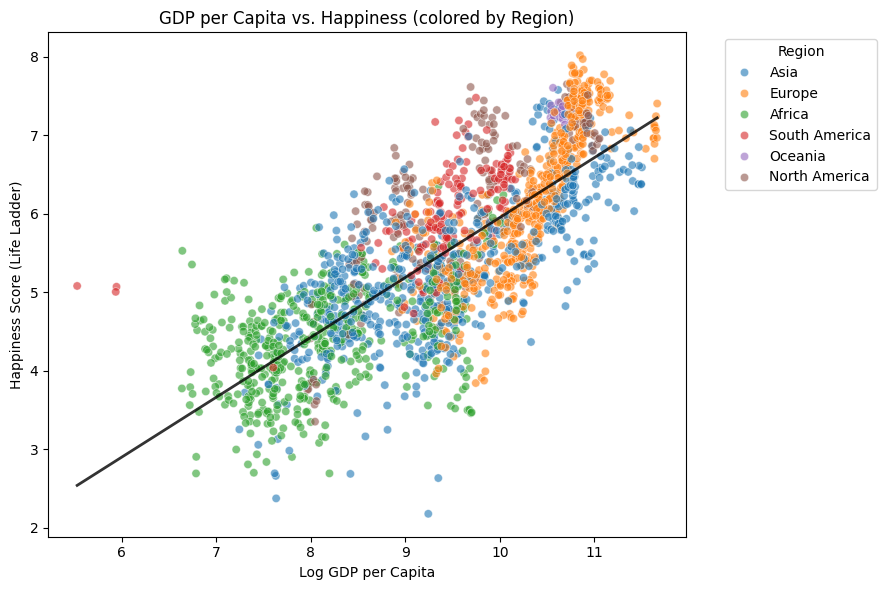

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_happiness,
    x='log_gdp_per_capita',
    y='life_ladder',
    hue='region' if 'region' in df_happiness.columns else None,
    alpha=0.6
)

#regression line to show overall trend
sns.regplot(
    data=df_happiness,
    x='log_gdp_per_capita',
    y='life_ladder',
    scatter=False,
    ci=None,
    line_kws={'linewidth': 2, 'alpha': 0.8, 'color': 'black'}
)

plt.title("GDP per Capita vs. Happiness" + (" (colored by Region)" if 'region' in df_happiness.columns else ""))
plt.xlabel("Log GDP per Capita")
plt.ylabel("Happiness Score (Life Ladder)")
if 'region' in df_happiness.columns:
    plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Results:**

This scatterplot confirms that GDP per capita is strongly associated with happiness, but it also shows diminishing returns at higher income levels. Regional patterns reveal that while Europe and North America tend to cluster at the high end of both GDP and happiness, South America appears relatively happier than their GDP alone would predict, while many African nations cluster at the lower end. Outliers suggest that factors beyond money, such as social support or governance, may help explain why some countries are happier than expected.


## Scatterplot for Social Support Vs. Happiness

Social support was one of the strongest correlates of happiness in the heatmap; this scatter checks how life satisfaction varies with perceived social support and whether the pattern differs by region.

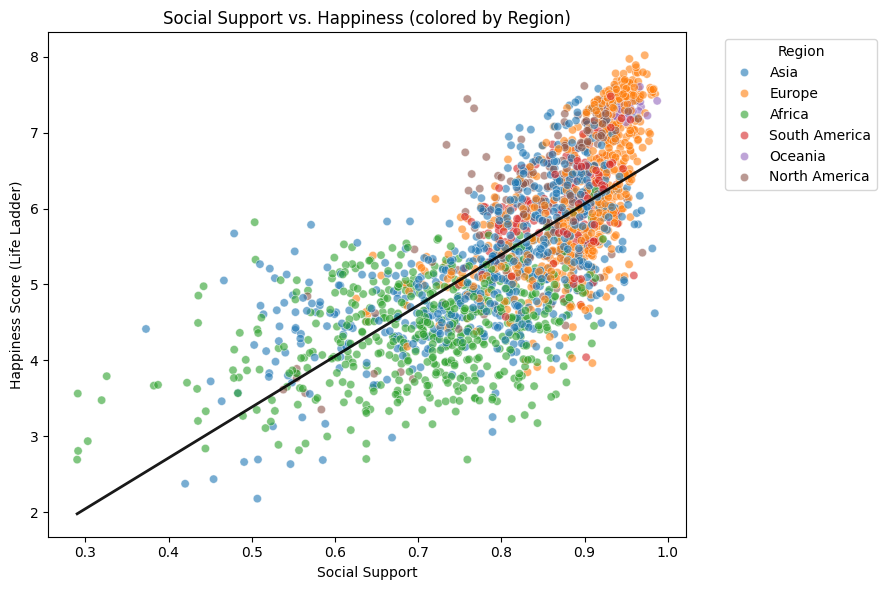

In [76]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_happiness,
    x='social_support',
    y='life_ladder',
    hue='region',
    alpha=0.6
)

# Overall regression line
sns.regplot(
    data=df_happiness,
    x='social_support',
    y='life_ladder',
    scatter=False,
    ci=None,
    line_kws={'linewidth': 2, 'alpha': 0.9, 'color': 'black'}
)

plt.title("Social Support vs. Happiness (colored by Region)")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score (Life Ladder)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Results:**

This scatterplot shows that social support is strongly linked with happiness, often just as much as GDP. Regions like South America appear happier than their income levels alone would predict, which may reflect the importance of strong social networks. Meanwhile, some African and Asian countries fall below the line, suggesting that while social support helps, other factors such as health, governance, or conflict may limit happiness.


## Boxplot of Happiness by Region

A boxplot by region makes it easy to compare the distribution of happiness scores across broad parts of the world, highlighting both the median scores and the variability within each region.

/var/folders/0w/0z2byg_114s3vhmjkpslm3dr0000gn/T/ipykernel_49831/2606137622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


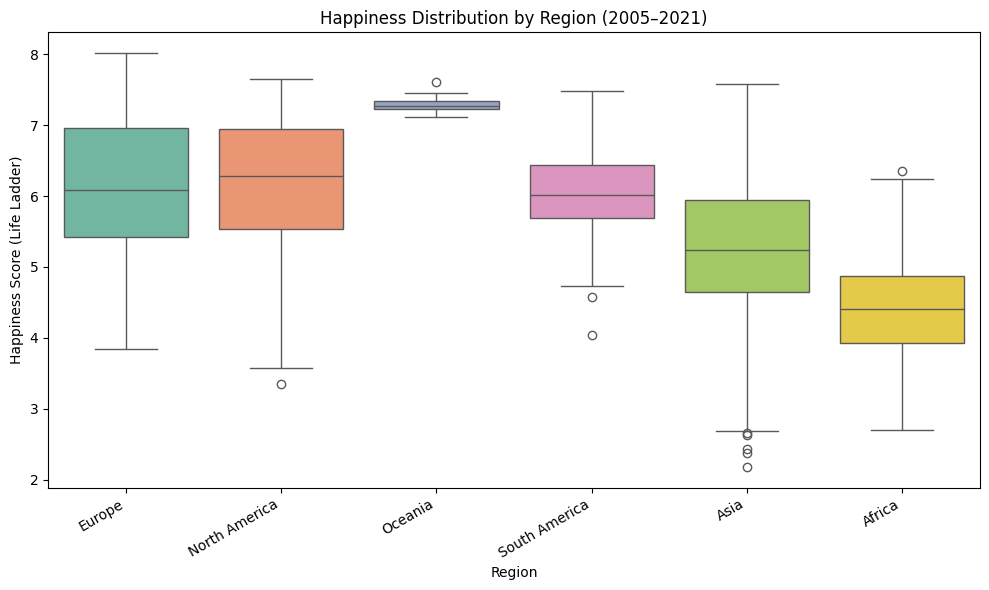

In [77]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_happiness,
    x='region',
    y='life_ladder',
    order=['Europe','North America','Oceania','South America','Asia','Africa'],
    palette="Set2"
)

plt.title("Happiness Distribution by Region (2005–2021)")
plt.xlabel("Region")
plt.ylabel("Happiness Score (Life Ladder)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Results:**

The boxplot highlights clear regional differences in happiness between 2005 and 2021. Europe, North America, and Oceania tend to report the highest median happiness scores, with Oceania showing both high and stable values. South America generally sits in the middle but leans toward higher happiness despite lower GDP levels, reinforcing the importance of non-economic factors like social support. Asia shows a wide spread, reflecting its diverse range of countries, while Africa consistently reports the lowest happiness scores overall, with several low outliers. These differences suggest that geography and regional conditions play a strong role in shaping well-being.


## Line Plot of Average Happiness by Region Over Time

A line plot of average happiness over time helps reveal whether regions are getting happier or less happy, and whether global events like the 2008 financial crisis or the COVID-19 pandemic in 2020 are visible in the trends.

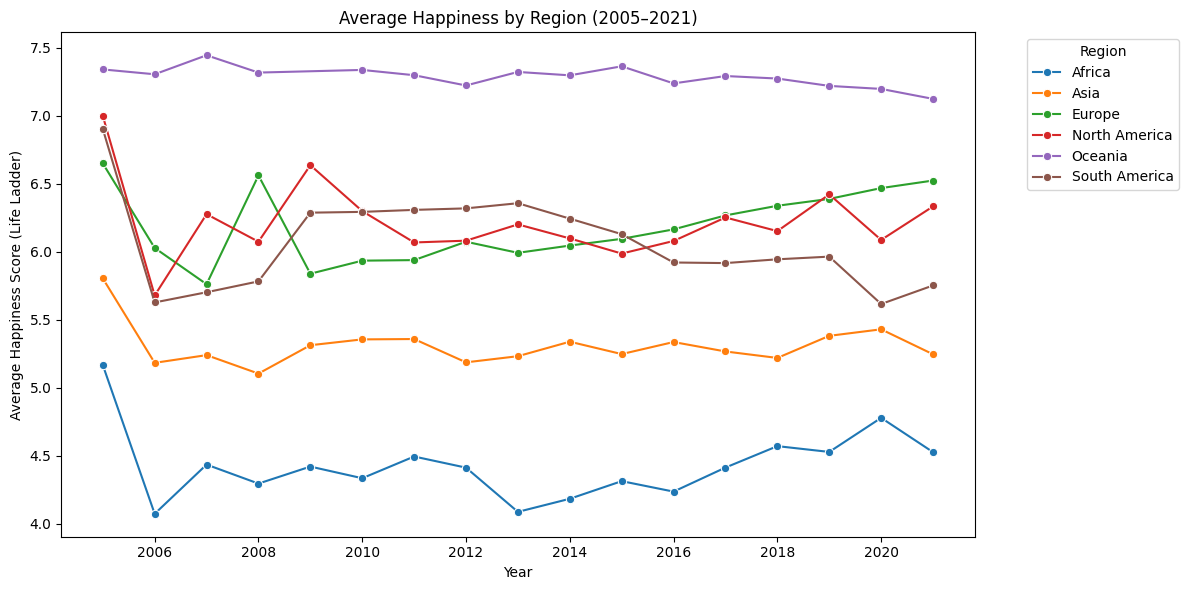

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average happiness by region and year
avg_happiness = (
    df_happiness
    .groupby(['year','region'])['life_ladder']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_happiness,
    x='year',
    y='life_ladder',
    hue='region',
    marker='o'
)

plt.title("Average Happiness by Region (2005–2021)")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score (Life Ladder)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Results:**

The line plot shows clear and persistent differences in happiness across regions from 2005 to 2021. Oceania consistently leads, while Africa remains lowest with little long-term change. Europe shows gradual improvement, recovering from a dip after the 2008 financial crisis. North America begins high but becomes more volatile, while South America maintains relatively strong happiness until recent declines. Asia shows a flat pattern, reflecting a mix of diverse outcomes across countries. These trends also reveal global events: the 2008 financial crisis and the COVID-19 pandemic both appear as dips in multiple regions.
